# Backbone Model - Huấn luyện mô hình sử dụng backbone EfficientNet-B0

---

Mục tiêu là sử dụng mô hình `EfficientNet-B0` để huấn luyện mô hình dự đoán quét mặt gian lận

In [1]:
import os
import sys
import numpy as np
from math import ceil
from pathlib import Path

import tensorflow as tf
from keras.optimizers import AdamW
from keras.optimizers.schedules import CosineDecay
from keras.losses import BinaryFocalCrossentropy
from keras.utils import set_random_seed
from keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

sys.path.append(os.path.abspath('..'))
from models.BackboneModel import backbone_model
from src.data import build_balanced_train_ds, build_eval_ds, clear_cache
from src.evaluate import MetricsCallback, plot_training_history, evaluate_model

I0000 00:00:1791545990.087457  628323 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791545990.527998  628323 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791545992.158391  628323 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
IMG_SIZE = 224
EPOCHS = 30
WARMUP_EPOCHS = 5
BATCH_SIZE = 32
SEED = 42
OUTPUT_DIR = '../outputs/backbone-model'
CACHE = '../cache/backbone-model'

set_random_seed(SEED)

import shutil
if os.path.exists(CACHE):
    shutil.rmtree(CACHE)
os.makedirs(CACHE, exist_ok=True)
clear_cache(CACHE)

## 1. Chuẩn bị dữ liệu

---

In [3]:
train_dir = '../datasets/LCC_FASD/train'
val_dir   = '../datasets/LCC_FASD/val'
test_dir  = '../datasets/LCC_FASD/test'

train_ds = build_balanced_train_ds(train_dir, IMG_SIZE, BATCH_SIZE, cache_dir=CACHE, seed=SEED)
val_ds   = build_eval_ds(val_dir,  IMG_SIZE, BATCH_SIZE, 'val',  cache_dir=CACHE)
test_ds  = build_eval_ds(test_dir, IMG_SIZE, BATCH_SIZE, 'test', cache_dir=CACHE)

x, y = next(iter(train_ds))
print(x.shape, float(tf.reduce_min(x)), float(tf.reduce_max(x)), int(tf.reduce_sum(y)))

Train: 1219 real | 7004 spoof | mỗi batch 16 real + 16 spoof


E0000 00:00:1791545994.105332  628323 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


val: 2934 ảnh
test: 7531 ảnh


W0000 00:00:1791545996.487260  628630 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


(32, 224, 224, 3) 0.0 1.0 16


W0000 00:00:1791545999.361579  628323 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 2. Khởi tạo mô hình

---

Mô hình được xây dựng trong [CustomeModel](../models/CustomeModel.py)

In [4]:
input_shape = (IMG_SIZE, IMG_SIZE, 3)

model = backbone_model(input_shape=input_shape, num_classes=1, freeze_backbone=True)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [5]:
metrics_callback = MetricsCallback(val_dataset=val_ds, threshold_path=OUTPUT_DIR + '/best_threshold.txt')

callbacks = [
    metrics_callback,

    ModelCheckpoint(
        filepath=OUTPUT_DIR + '/best_model.keras', 
        monitor='val_acer', 
        save_best_only=True, 
        mode='min', 
        verbose=1
    ),

    EarlyStopping(
        monitor='val_acer',
        patience=5,
        mode='min',
        verbose=1,
        restore_best_weights=False
    )
]

num_train = sum(1 for p in Path(train_dir).rglob('*.png') if p.is_file())
steps_per_epoch = ceil(num_train / BATCH_SIZE)

lr_schedule_stage_1 = CosineDecay(
    initial_learning_rate=0.000363,
    decay_steps=EPOCHS * steps_per_epoch
)

# Giảm learning rate xuống 0.0001 nhằm bảo vệ backbone
lr_schedule_stage_2 = CosineDecay(
    initial_learning_rate=0.0001,
    decay_steps=(EPOCHS - WARMUP_EPOCHS) * steps_per_epoch
)

W0000 00:00:1791546003.068648  628323 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 3. Huấn luyện mô hình

---

### 3.1 Giai đoạn 1 - Warm-up

In [6]:
model.compile(
    optimizer=AdamW(learning_rate=lr_schedule_stage_1, weight_decay=2e-3),
    loss=BinaryFocalCrossentropy(gamma=2.0),
    metrics=['accuracy']
)

history_stage_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    shuffle=False
)

Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8118 - loss: 0.1081 - APCER: 19.34% - BPCER: 19.26% - EER: 19.30% - ACER: 19.30% (t*: 0.5328) ⭐ NEW BEST

Epoch 1: val_acer improved from None to 0.19297, saving model to ../outputs/backbone-model/best_model.keras

Epoch 1: finished saving model to ../outputs/backbone-model/best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 174s 650ms/step - accuracy: 0.8118 - loss: 0.1081 - val_accuracy: 0.8432 - val_loss: 0.0818 - val_apcer: 0.1934 - val_bpcer: 0.1926 - val_eer: 0.1930 - val_acer: 0.1930
Epoch 2/5
 23/257 ━━━━━━━━━━━━━━━━━━━━ 1:32 397ms/step - accuracy: 0.8478 - loss: 0.0922

W0000 00:00:1791546186.242308  628833 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.8924 - loss: 0.0702 - APCER: 12.85% - BPCER: 12.84% - EER: 12.85% - ACER: 12.85% (t*: 0.5402) ⭐ NEW BEST

Epoch 2: val_acer improved from 0.19297 to 0.12845, saving model to ../outputs/backbone-model/best_model.keras

Epoch 2: finished saving model to ../outputs/backbone-model/best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 163s 635ms/step - accuracy: 0.8924 - loss: 0.0702 - val_accuracy: 0.8916 - val_loss: 0.0671 - val_apcer: 0.1285 - val_bpcer: 0.1284 - val_eer: 0.1285 - val_acer: 0.1285
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.8880 - loss: 0.0710 - APCER: 14.31% - BPCER: 14.07% - EER: 14.19% - ACER: 14.19% (t*: 0.4277) 

Epoch 3: val_acer did not improve from 0.12845
257/257 ━━━━━━━━━━━━━━━━━━━━ 163s 636ms/step - accuracy: 0.8880 - loss: 0.0710 - val_accuracy: 0.8064 - val_loss: 0.1119 - val_apcer: 0.1431 - val_bpcer: 0.1407 - val_eer: 0.1419 - val_acer: 0.1419
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 

### 3.2 Giai đoạn 2 - Mở khóa toàn bộ mô hình

In [7]:
from keras.layers import BatchNormalization

backbone = model.get_layer('efficientnetb0')
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False
for layer in backbone.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=AdamW(learning_rate=lr_schedule_stage_2, weight_decay=2e-3),
    loss=BinaryFocalCrossentropy(gamma=2.0),
    metrics=['accuracy']
)

history_stage_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=WARMUP_EPOCHS,
    epochs=EPOCHS,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    shuffle=False
)

Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9324 - loss: 0.0439 - APCER: 9.61% - BPCER: 9.63% - EER: 9.62% - ACER: 9.62% (t*: 0.5943) ⭐ NEW BEST

Epoch 6: val_acer improved from 0.12381 to 0.09619, saving model to ../outputs/backbone-model/best_model.keras

Epoch 6: finished saving model to ../outputs/backbone-model/best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 188s 710ms/step - accuracy: 0.9324 - loss: 0.0439 - val_accuracy: 0.9383 - val_loss: 0.0440 - val_apcer: 0.0961 - val_bpcer: 0.0963 - val_eer: 0.0962 - val_acer: 0.0962
Epoch 7/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9576 - loss: 0.0327 - APCER: 11.86% - BPCER: 11.85% - EER: 11.86% - ACER: 11.86% (t*: 0.6143) 

Epoch 7: val_acer did not improve from 0.09619
257/257 ━━━━━━━━━━━━━━━━━━━━ 179s 697ms/step - accuracy: 0.9576 - loss: 0.0327 - val_accuracy: 0.9250 - val_loss: 0.0488 - val_apcer: 0.1186 - val_bpcer: 0.1185 - val_eer: 0.1186 - val_acer: 0.1186
Epoch 8/30
257/257 ━━━━━━━━━━━━━━━

In [8]:
combined_history = {}

for key in history_stage_1.history.keys():
    combined_history[key] = history_stage_1.history[key] + history_stage_2.history[key]

# 4. Đánh giá kết quả 

---

In [9]:
from keras.models import load_model

model = load_model(OUTPUT_DIR + '/best_model.keras')
threshold_best = float(open(OUTPUT_DIR + '/best_threshold.txt').read())
print(f"Ngưỡng tốt nhất: {threshold_best}")

y_prob = model.predict(test_ds)
y_pred = (y_prob >= threshold_best).astype(int).flatten()

y_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in test_ds], axis=0).flatten()

print(classification_report(y_true, y_pred))

Ngưỡng tốt nhất: 0.4868980348110199
236/236 ━━━━━━━━━━━━━━━━━━━━ 127s 529ms/step


W0000 00:00:1791548561.030239  628323 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


              precision    recall  f1-score   support

         0.0       0.27      0.88      0.42       314
         1.0       0.99      0.90      0.94      7217

    accuracy                           0.90      7531
   macro avg       0.63      0.89      0.68      7531
weighted avg       0.96      0.90      0.92      7531



Đã lưu biểu đồ lịch sử tại: ../outputs/backbone-model/training_history.png


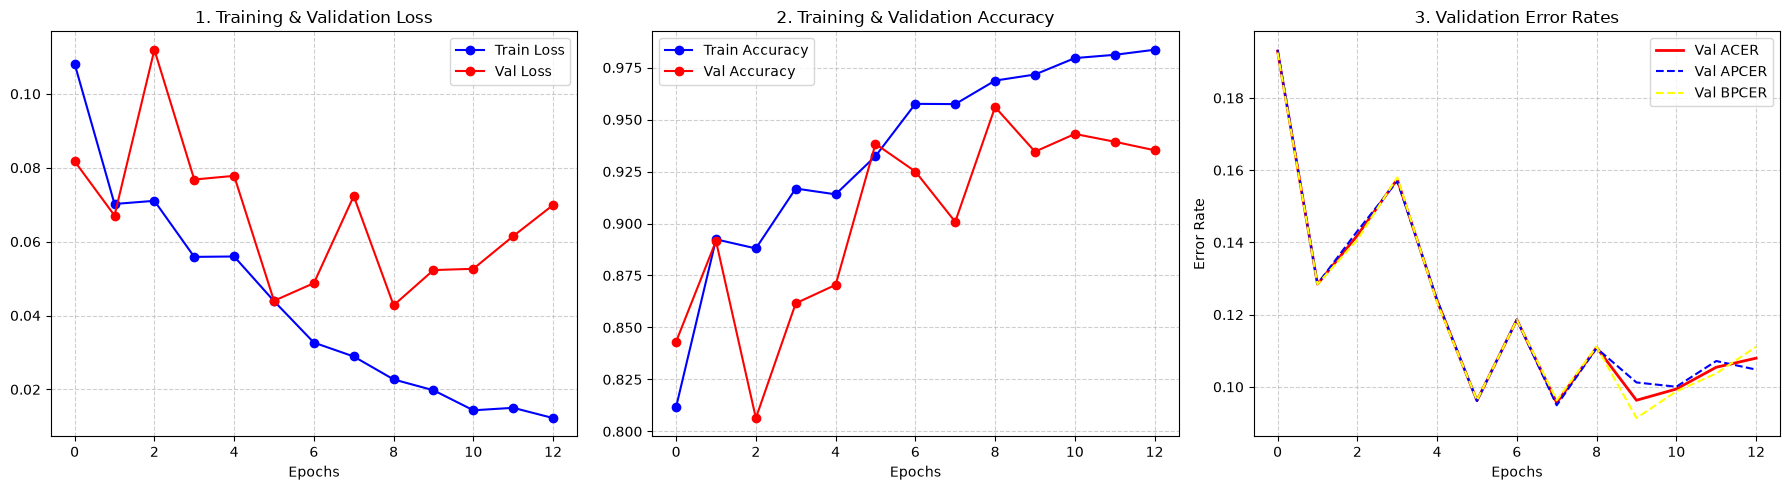

In [10]:
plot_training_history(combined_history, output=OUTPUT_DIR + '/training_history.png')

In [11]:
y_val_prob = model.predict(val_ds)
y_val_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in val_ds], axis=0).flatten()

92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 500ms/step


Đã lưu biểu đồ tại: ../outputs/backbone-model/evaluation_report.png


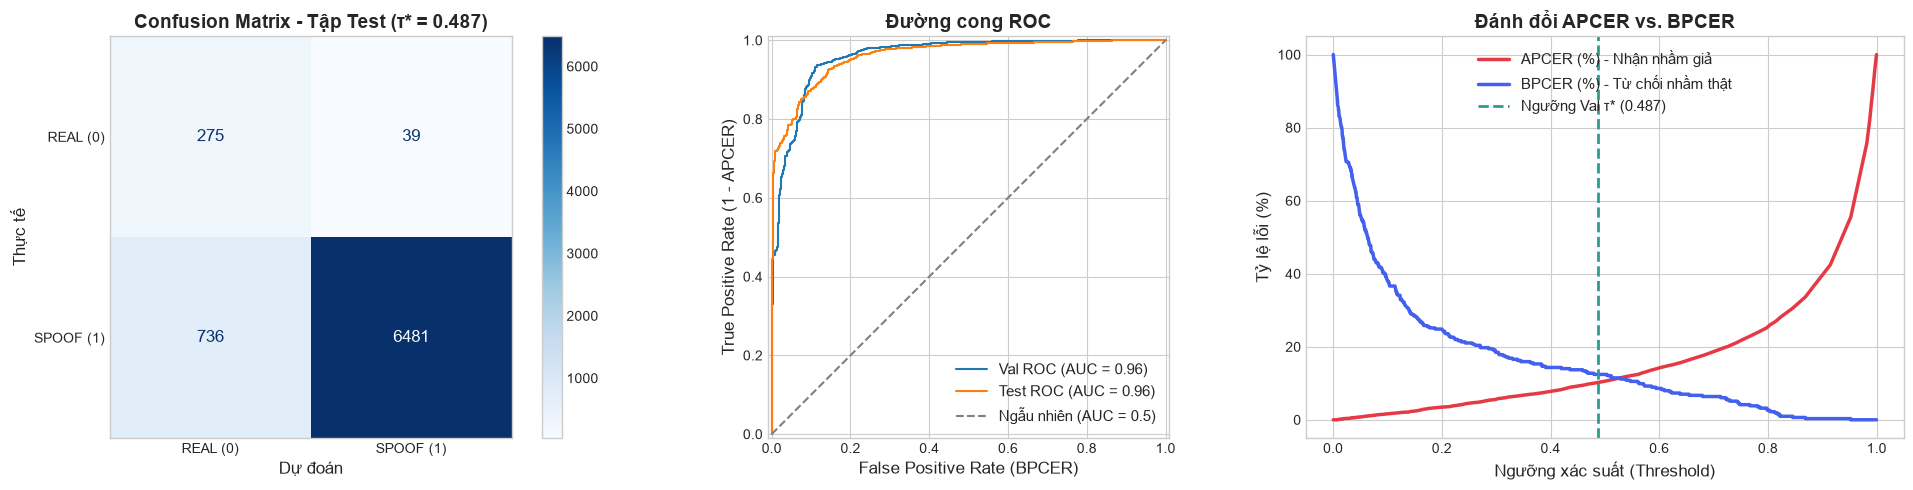

In [12]:
# Đánh giá và vẽ biểu đồ
y_test = (y_true, y_prob)
y_val = (y_val_true, y_val_prob)

evaluate_model(y_test, y_val, threshold_best, output=OUTPUT_DIR + '/evaluation_report.png')